#Decision Tree Classifier

In [1]:
# Import needed libraries
import sys
assert sys.version_info >= (3, 7)

from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [2]:
#Define the default font sizes to make the figures prettier.
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [3]:
#Create the images/decision_trees folder, and define the save_fig()
#function to save the figures in high-res.
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_trees"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

##Training and Visualizing a Decision Tree

In [4]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
print(iris.frame.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [5]:
print(iris.frame.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [6]:
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

In [7]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [8]:
from sklearn.tree import export_graphviz

export_graphviz(
        tree_clf,
        out_file=str(IMAGES_PATH / "iris_tree.dot"),
        feature_names=["petal length (cm)", "petal width (cm)"],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

In [9]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "iris_tree.dot")

ModuleNotFoundError: No module named 'graphviz'

In [10]:
print("Feature importances for tree_clf (all features):\n")
for name, importance in zip(iris.feature_names, tree_clf.feature_importances_):
    print(f"{name}: {importance:.4f}")

Feature importances for tree_clf (all features):

sepal length (cm): 0.5620
sepal width (cm): 0.4380


In [11]:
#help(DecisionTreeClassifier)

##Using all the features

In [12]:
X1_iris = iris.data[["petal length (cm)", "petal width (cm)", "sepal length (cm)","sepal width (cm)" ]].values
y_iris = iris.target

In [13]:
tree_clf1 = DecisionTreeClassifier( random_state=42)
tree_clf1.fit(X1_iris, y_iris)

DecisionTreeClassifier(random_state=42)

In [14]:
from sklearn.tree import export_graphviz

export_graphviz(
        tree_clf1,
        out_file=str(IMAGES_PATH / "iris_tree1.dot"),
        feature_names=["petal length (cm)", "petal width (cm)", "sepal length (cm)","sepal width (cm)"],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

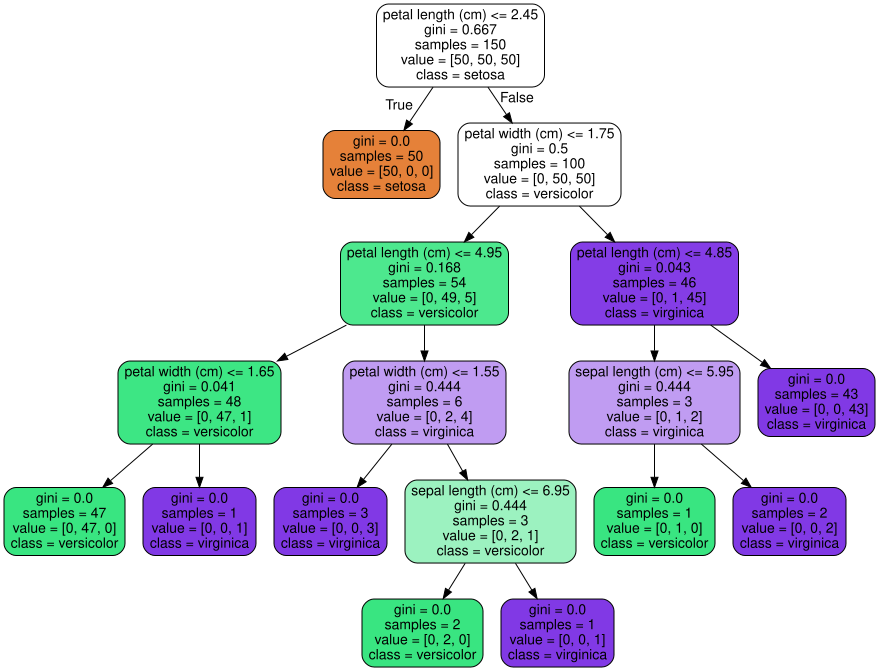

In [15]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "iris_tree1.dot")

In [16]:
print("Feature importances for tree_clf1 (all features):\n")
for name, importance in zip(iris.feature_names, tree_clf1.feature_importances_):
    print(f"{name}: {importance:.4f}")

Feature importances for tree_clf1 (all features):

sepal length (cm): 0.5507
sepal width (cm): 0.4226
petal length (cm): 0.0267
petal width (cm): 0.0000


#Generated Movie Dataset


In [17]:
import numpy as np

np.random.seed(42) # Set a random seed for reproducibility

# 1. Define n_samples_revised as 10 for the number of observations per class
n_samples = 10

# 2. For 'Critical Success' class:
#    a. Generate 'A-list Celebrities' scores
celeb_cs = np.random.normal(loc=6.5, scale=2, size=n_samples)
celeb_cs = np.clip(celeb_cs, 0, 10) # Ensure values are within 0-10

#    b. Generate 'Estimated budget $' values
budget_cs = np.random.normal(loc=60, scale=20, size=n_samples)
budget_cs = np.maximum(budget_cs, 1) # Ensure values are positive (min 1 million)

# 3. For 'Mainstream Hit' class:
#    a. Generate 'A-list Celebrities' scores
celeb_mh = np.random.normal(loc=5.5, scale=1.0, size=n_samples-1)
celeb_mh = np.clip(celeb_mh, 0, 10) # Ensure values are within 0-10
celeb_mh = np.append(celeb_mh, 3) # Add one significantly low number of celebreties

#    b. Generate 'Estimated budget $' values
budget_mh = np.random.normal(loc=150, scale=30, size=n_samples)
budget_mh = np.maximum(budget_mh, 1) # Ensure values are positive (min 1 million)

# 4. For 'Box Office Bust' class:
#    a. Generate 'A-list Celebrities' scores
celeb_bob = np.random.normal(loc=1.5, scale=1.75, size=n_samples)
celeb_bob = np.clip(celeb_bob, 0, 10) # Ensure values are within 0-10

#    b. Generate 'Estimated budget $' values (8 values + 1 high value + 1 medium)
budget_bob_temp = np.random.normal(loc=45, scale=35, size=n_samples - 2)
budget_bob_temp = np.maximum(budget_bob_temp, 1) # Ensure values are positive (min 1 million)
budget_bob = np.append(budget_bob_temp, 170) # Add one significantly high budget value
budget_bob1 = np.append(budget_bob, 110) # Add one significantly medium budget value


# 5. Create class labels for each class
labels_cs = np.array(['Critical Success'] * n_samples)
labels_mh = np.array(['Mainstream Hit'] * n_samples)
labels_bob = np.array(['Box Office Bust'] * n_samples)

print("New synthetic data generated for 'Critical Success', 'Mainstream Hit', and 'Box Office Bust' classes (10 samples each) with revised parameters.")

New synthetic data generated for 'Critical Success', 'Mainstream Hit', and 'Box Office Bust' classes (10 samples each) with revised parameters.


In [18]:
import pandas as pd

# Combine data for all classes into single arrays
alist_celebrities = np.concatenate([celeb_cs, celeb_mh, celeb_bob])
estimated_budget = np.concatenate([budget_cs, budget_mh, budget_bob1])
class_labels = np.concatenate([labels_cs, labels_mh, labels_bob])

# Create a pandas DataFrame
df_movie = pd.DataFrame({
    'A-list Celebrities': alist_celebrities,
    'Estimated budget $': estimated_budget,
    'Class': class_labels
})

# Display the head of the DataFrame
print("DataFrame created successfully. Here's the head of the revised dataset:")
print(df_movie.head())

DataFrame created successfully. Here's the head of the revised dataset:
   A-list Celebrities  Estimated budget $             Class
0            7.493428           50.731646  Critical Success
1            6.223471           50.685405  Critical Success
2            7.795377           64.839245  Critical Success
3            9.546060           21.734395  Critical Success
4            6.031693           25.501643  Critical Success


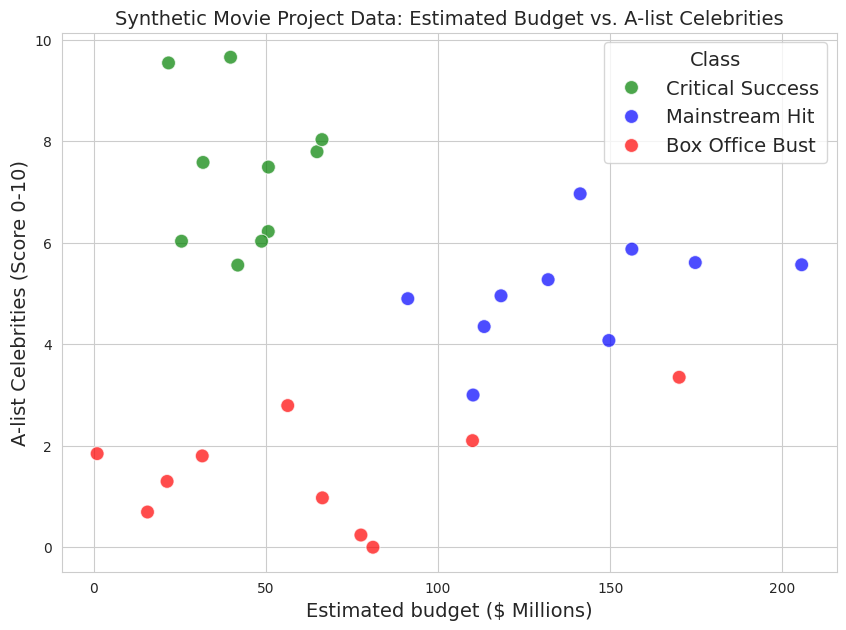

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

# Create the scatter plot for the new dataset
plt.figure(figsize=(10, 7))
colors = {'Critical Success': 'green', 'Mainstream Hit': 'blue', 'Box Office Bust': 'red'}

sns.scatterplot(
    data=df_movie,
    x='Estimated budget $',
    y='A-list Celebrities',
    hue='Class',
    palette=colors,
    s=100, # Adjust marker size
    alpha=0.7 # Adjust transparency
)

# Add labels and title
plt.title('Synthetic Movie Project Data: Estimated Budget vs. A-list Celebrities')
plt.xlabel('Estimated budget ($ Millions)')
plt.ylabel('A-list Celebrities (Score 0-10)')

# Add a legend
plt.legend(title='Class')

# Show the plot
plt.show()

## Define Features and Target



In [20]:
X_movie = df_movie[['A-list Celebrities', 'Estimated budget $']]
y_movie = df_movie['Class']

print("Features (X_movie) created successfully:")
print(X_movie.head())
print("\nTarget (y_movie) created successfully:")
print(y_movie.head())

Features (X_movie) created successfully:
   A-list Celebrities  Estimated budget $
0            7.493428           50.731646
1            6.223471           50.685405
2            7.795377           64.839245
3            9.546060           21.734395
4            6.031693           25.501643

Target (y_movie) created successfully:
0    Critical Success
1    Critical Success
2    Critical Success
3    Critical Success
4    Critical Success
Name: Class, dtype: object


## Train Decision Tree Classifier

Initialize and train a DecisionTreeClassifier with max_depth=2 using the defined features (X) and target (y). This will ensure the tree has exactly two splits.


In [21]:
from sklearn.tree import DecisionTreeClassifier

tree_clf_movie = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_movie.fit(X_movie, y_movie)

print("DecisionTreeClassifier for movie dataset trained successfully.")

DecisionTreeClassifier for movie dataset trained successfully.


Decision tree exported to movie_tree.dot. Now visualizing...


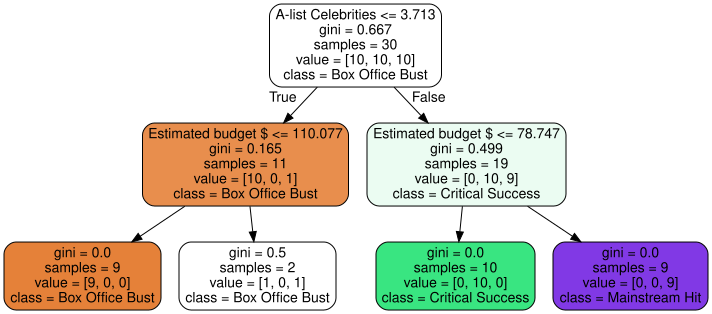

In [22]:
from sklearn.tree import export_graphviz
from graphviz import Source

# Prepare feature names and class names for visualization
feature_names_movie = X_movie.columns.tolist()
class_names_movie = tree_clf_movie.classes_.tolist()

export_graphviz(
    tree_clf_movie,
    out_file=str(IMAGES_PATH / "movie_tree.dot"),
    feature_names=feature_names_movie,
    class_names=class_names_movie,
    rounded=True,
    filled=True
)

print("Decision tree exported to movie_tree.dot. Now visualizing...")
Source.from_file(IMAGES_PATH / "movie_tree.dot")

# Decision Tree Regressor
Using generated numerical data

In [23]:
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5  # a single random input feature
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

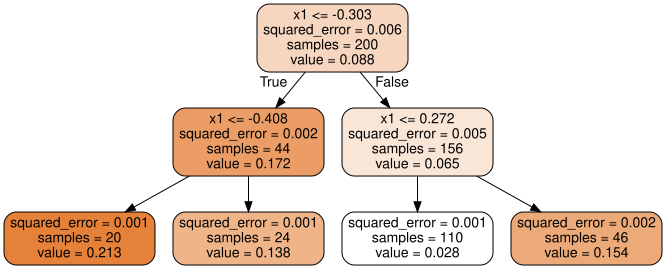

In [24]:
export_graphviz(
    tree_reg,
    out_file=str(IMAGES_PATH / "regression_tree.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file(IMAGES_PATH / "regression_tree.dot")

In [25]:
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg2.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=3, random_state=42)

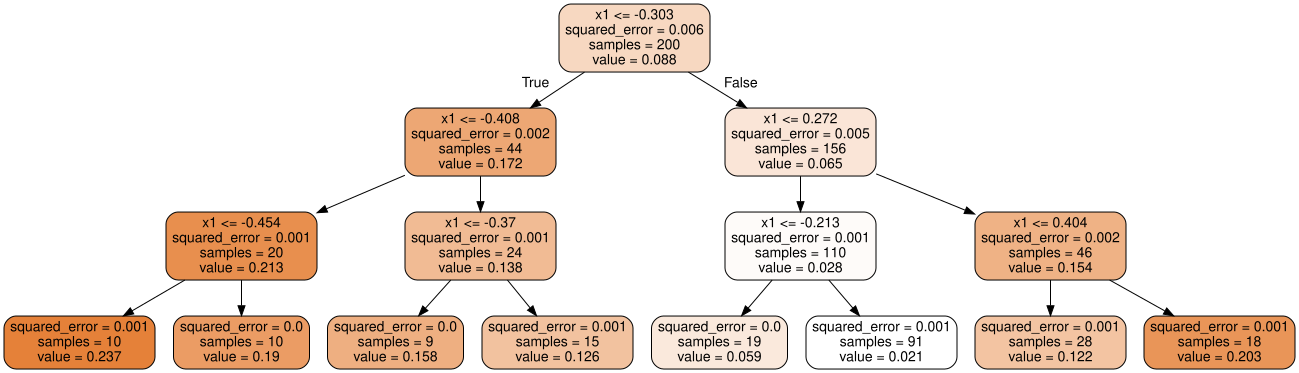

In [26]:
export_graphviz(
    tree_reg2,
    out_file=str(IMAGES_PATH / "regression_tree.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file(IMAGES_PATH / "regression_tree.dot")

#Find the best parameters

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor # Import DecisionTreeRegressor

params = {
    'max_leaf_nodes': list(range(2, 100)),
    'max_depth': list(range(1, 7)),
    'min_samples_split': [2, 3, 4]
}
# Change DecisionTreeClassifier to DecisionTreeRegressor
grid_search_cv = GridSearchCV(DecisionTreeRegressor(random_state=42),
                              params,
                              cv=3)

grid_search_cv.fit(X_quad, y_quad)

GridSearchCV(cv=3, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4]})

In [31]:
best_tree_reg = grid_search_cv.best_estimator_

In [32]:
from sklearn.metrics import mean_squared_error

y_pred = best_tree_reg.predict(X_quad)
mse = mean_squared_error(y_quad, y_pred)

print(f"The Mean Squared Error for the best regression tree is: {mse:.4f}")

The Mean Squared Error for the best regression tree is: 0.0005


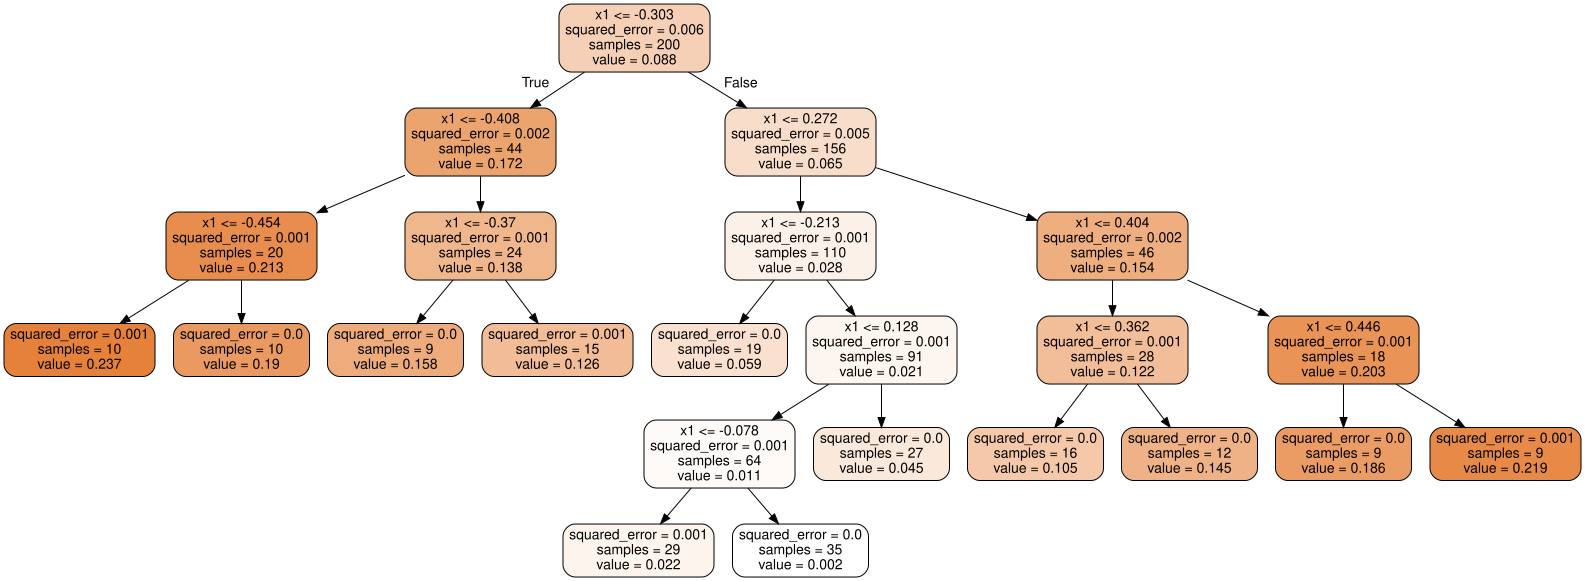

In [33]:
from sklearn.tree import export_graphviz
from graphviz import Source

export_graphviz(
    best_tree_reg,
    out_file=str(IMAGES_PATH / "best_regression_tree.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file(IMAGES_PATH / "best_regression_tree.dot")